### **演習問題 3-3**

In [1]:
file = "./cloud.mp4"

In [2]:
# Capturing
import cv2
vid = cv2.VideoCapture(file)
print(vid.isOpened())

True


In [3]:
# Show Info.
print("Frame Size: "+str(vid.get(cv2.CAP_PROP_FRAME_WIDTH))+','+str(vid.get(cv2.CAP_PROP_FRAME_HEIGHT)))
print("Frame Num.: "+str(vid.get(cv2.CAP_PROP_FRAME_COUNT)))

Frame Size: 1280.0,720.0
Frame Num.: 469.0


In [4]:
# Read 1 Frame
ret, data = vid.read()
print(ret)
print(data.shape)
vid.release

True
(720, 1280, 3)


<function VideoCapture.release>

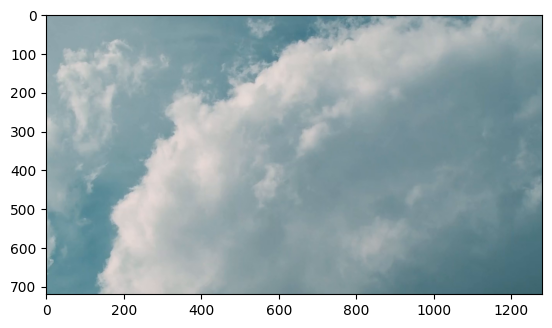

In [5]:
# Plot Image
import matplotlib.pyplot as plt
plt.imshow(data[:,:,::-1])

In [6]:
# Velocity by OF

import cv2
vid = cv2.VideoCapture(file)
print(vid.isOpened())

ret, data_ori = vid.read()
ret, data_nxt = vid.read()
vid.release

ori = cv2.cvtColor(data_ori,cv2.COLOR_BGR2GRAY)
nxt = cv2.cvtColor(data_nxt, cv2.COLOR_BGR2GRAY)
vel = cv2.calcOpticalFlowFarneback(ori, nxt, None, 0.5, 3, 20, 3, 5, 1.2, 0)



True


In [7]:
def flow_vector(flow, spacing, margin, minlength):
    """
    Parameters:
    input
    flow: motion vectors 3D-array
    spacing: pixel spacing of the flow
    margin: pixel margins of the flow
    minlength: minimum pixels to leave as flow
    output
    x: x coord 1D-array
    y: y coord 1D-array
    u: x direction flow vector 2D-array
    v: y direction flow vector 2D-array

    From https://qiita.com/yusuke_s_yusuke/items/03243490b1fd765fe61f
    """
    h, w, _ = flow.shape

    x = np.arange(margin, w - margin, spacing, dtype=np.int64)
    y = np.arange(margin, h - margin, spacing, dtype=np.int64)

    mesh_flow = flow[np.ix_(y, x)]
    mag, _ = cv2.cartToPolar(mesh_flow[..., 0], mesh_flow[..., 1])
    mesh_flow[mag < minlength] = np.nan  # minlength以下をnanに置換

    u = mesh_flow[..., 0]
    v = mesh_flow[..., 1]

    return x, y, u, v

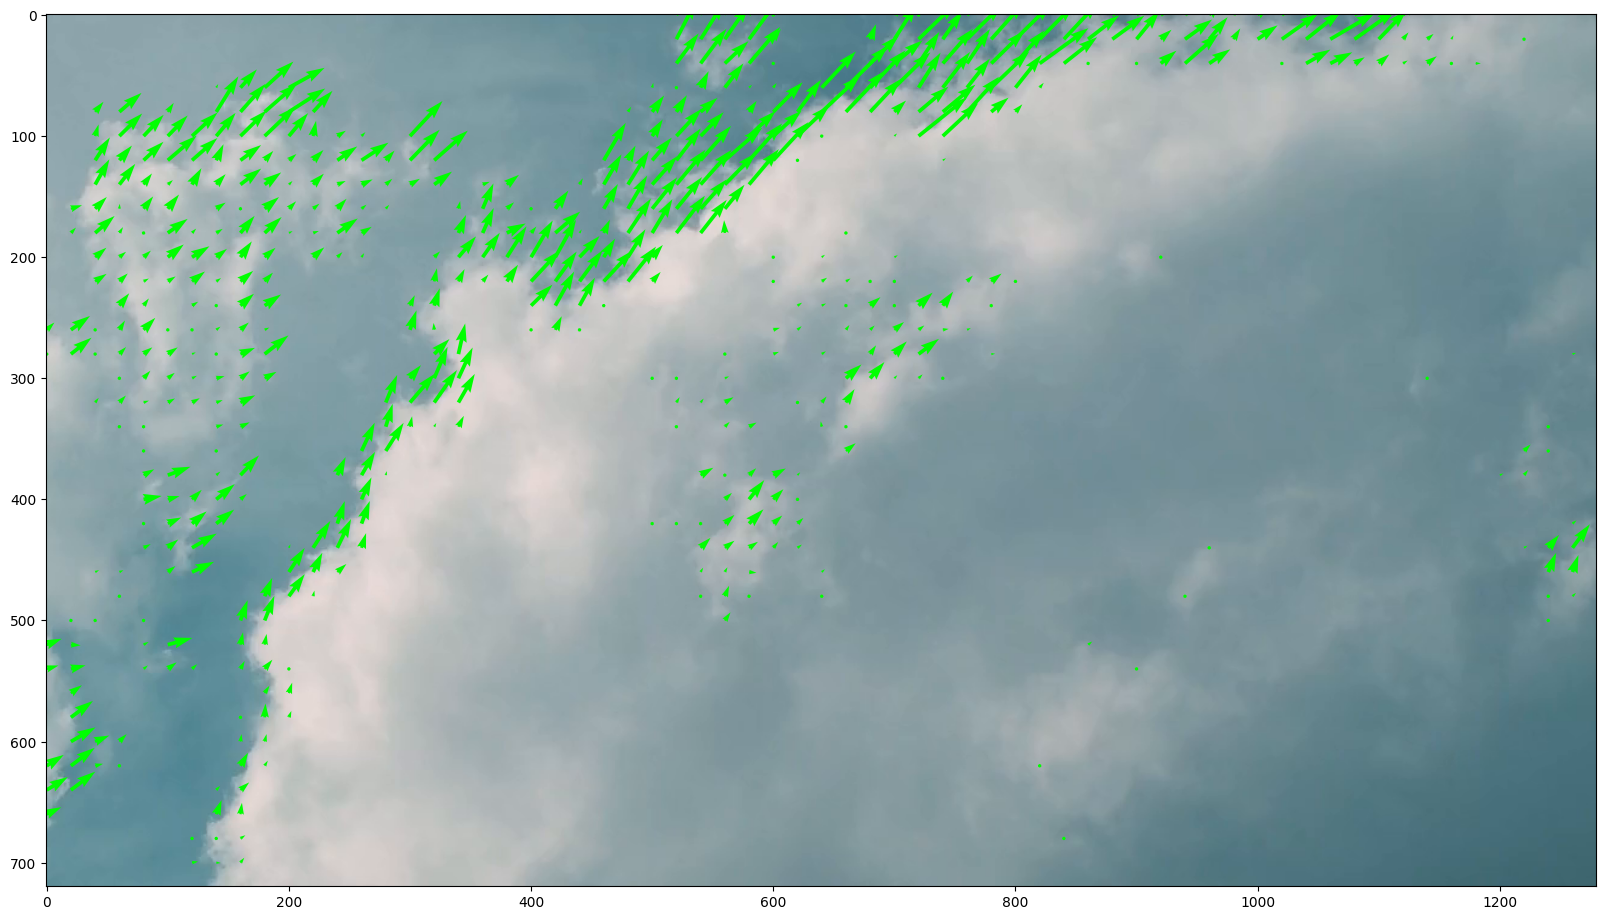

In [8]:
import numpy as np
fig, ax = plt.subplots(figsize=(20, 12))
ax.imshow(data_ori[:,:,::-1])
x, y, u, v = flow_vector(flow=vel, spacing=20, margin=0, minlength=0.1)
ax.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=0.05, color=[0.0, 1.0, 0.0])